In [58]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [64]:
data = pd.read_csv(r"C:\Users\ammar\OneDrive\Desktop\Netflix Dataset.csv")
data.head(1)


,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...


In [10]:
data.shape

(7789, 11)

In [11]:
data.columns

Index(['Show_Id', 'Category', 'Title', 'Director', 'Cast', 'Country',
       'Release_Date', 'Rating', 'Duration', 'Type', 'Description'],
      dtype='object')

In [14]:
data.dtypes

Show_Id                 object
Category                object
Title                   object
Director                object
Cast                    object
Country                 object
Release_Date    datetime64[ns]
Rating                  object
Duration                object
Type                    object
Description             object
dtype: object

In [31]:
data['Release_Date'] = pd.to_datetime(data['Release_Date'], format='%d-%b-%y', errors='coerce')

data['Year'] = data['Release_Date'].dt.year


In [17]:
data[data.duplicated()]

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
6300,s684,Movie,Backfire,Dave Patten,"Black Deniro, Byron ""Squally"" Vinson, Dominic ...",United States,5-Apr-19,TV-MA,97 min,"Dramas, Independent Movies, Thrillers",When two would-be robbers accidentally kill a ...
6622,s6621,Movie,The Lost Okoroshi,Abba T. Makama,"Seun Ajayi, Judith Audu, Tope Tedela, Ifu Enna...",Nigeria,4-Sep-20,TV-MA,94 min,"Comedies, Dramas, Independent Movies",A disillusioned security guard transforms into...


In [18]:
data.drop_duplicates(inplace = True)

In [19]:
data.shape

(7787, 11)

In [20]:
data.isnull().sum()

Show_Id            0
Category           0
Title              0
Director        2388
Cast             718
Country          507
Release_Date      10
Rating             7
Duration           0
Type               0
Description        0
dtype: int64

<Axes: >

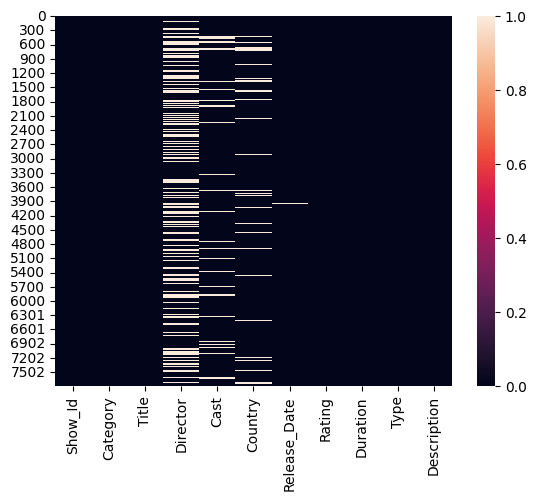

In [21]:
sns.heatmap(data.isnull())

In [26]:
data['Director'] = data['Director'].fillna("Unknown")
data['Cast'] = data['Cast'].fillna("Unknown")
data['Country'] = data['Country'].fillna("Unknown")
data['Rating'] = data['Rating'].fillna("Not Rated")

In [27]:
data.isnull().sum()

Show_Id          0
Category         0
Title            0
Director         0
Cast             0
Country          0
Release_Date    10
Rating           0
Duration         0
Type             0
Description      0
dtype: int64

In [35]:
#movies & tvshows
data.groupby('Category').Category.count()

Category
Movie      5377
TV Show    2410
Name: Category, dtype: int64

In [40]:
#top 5 countries 
data['Country'].value_counts().head()

Country
United States     2555
India              923
Unknown            507
United Kingdom     397
Japan              226
Name: count, dtype: int64

In [43]:
print("\nDataset covers years from", data['Year'].min(), "to", data['Year'].max())



Dataset covers years from 2008.0 to 2021.0


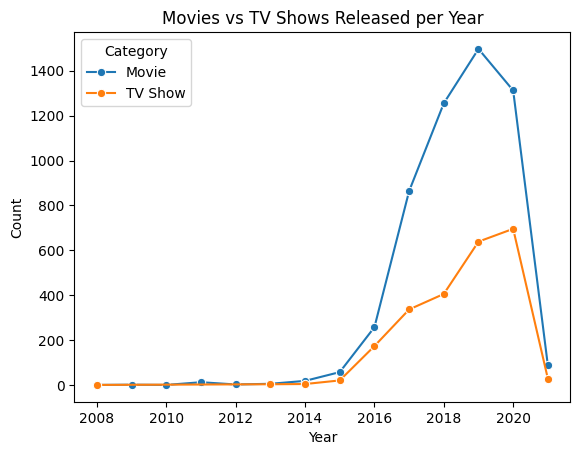

In [46]:
content_trend = data.groupby(['Year', 'Category']).size().reset_index(name='Count')
sns.lineplot(data=content_trend, x='Year', y='Count', hue='Category', marker='o')
plt.title("Movies vs TV Shows Released per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()


C:\Users\ammar\AppData\Local\Temp\ipykernel_14488\2509568369.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




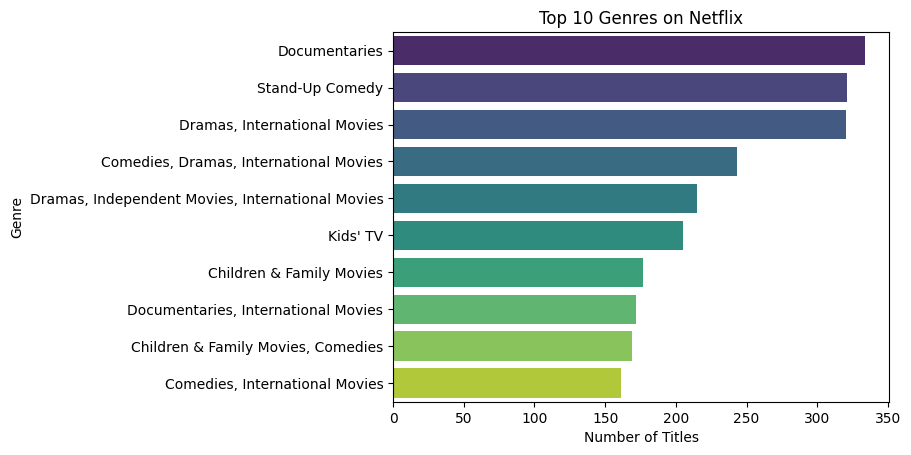

In [74]:
top_genres = data['Type'].value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, palette="viridis")
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.show()

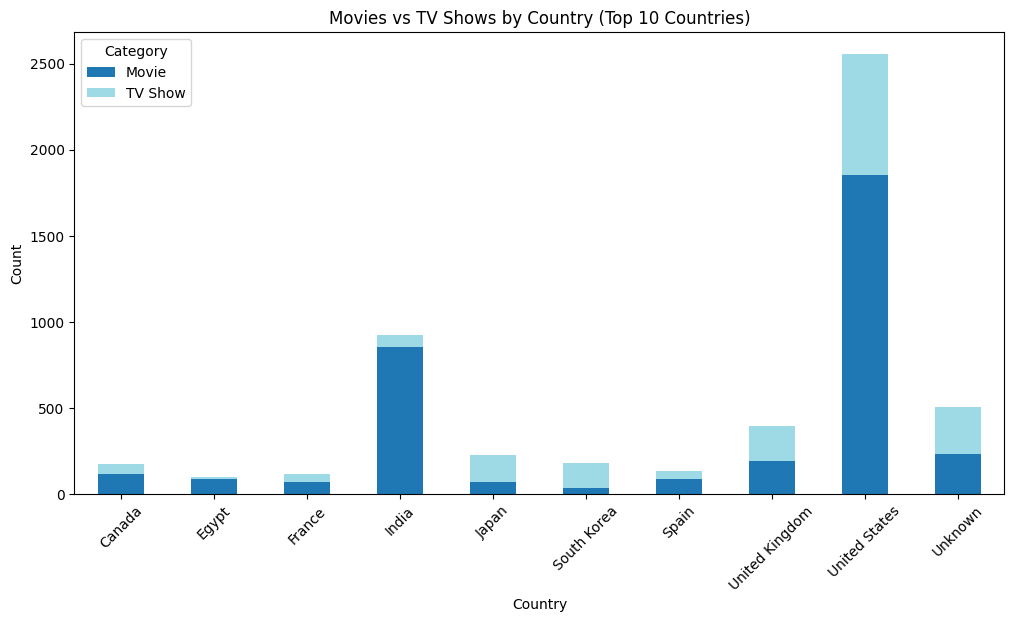

In [55]:
top_countries = data['Country'].value_counts().head(10).index
country_data = data[data['Country'].isin(top_countries)]
stacked = country_data.groupby(['Country', 'Category']).size().unstack(fill_value=0)
stacked.plot(kind='bar', stacked=True, figsize=(12,6), colormap="tab20")
plt.title("Movies vs TV Shows by Country (Top 10 Countries)")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

C:\Users\ammar\AppData\Local\Temp\ipykernel_14488\1368213921.py:4: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(country_counts, locations="Country", locationmode="country names",


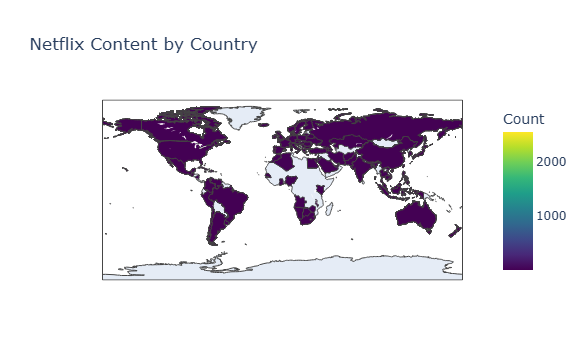

In [59]:
# 4. Choropleth Map – Country-wise Content
country_counts = data['Country'].value_counts().reset_index()
country_counts.columns = ['Country', 'Count']
fig = px.choropleth(country_counts, locations="Country", locationmode="country names",
                    color="Count", hover_name="Country",
                    color_continuous_scale="viridis", title="Netflix Content by Country")
fig.show()


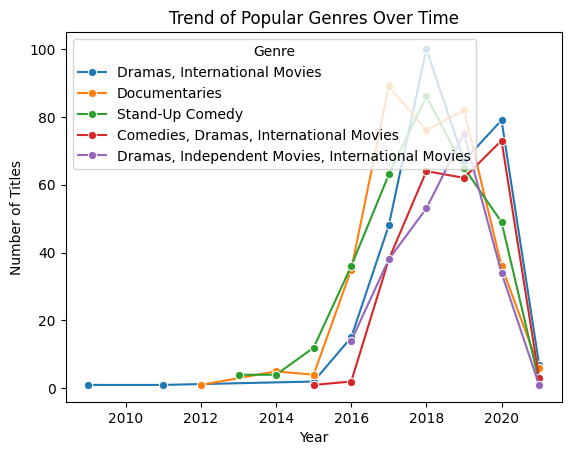

In [63]:
# 5. Trend Line – Growth of Popular Genres Over Time
popular_genres = data['Type'].value_counts().head(5).index
genre_trends = data[data['Type'].isin(popular_genres)].groupby(['Year','Type']).size().reset_index(name='Count')

sns.lineplot(data=genre_trends, x='Year', y='Count', hue='Type', marker="o")
plt.title("Trend of Popular Genres Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.legend(title="Genre")
plt.show()

C:\Users\ammar\AppData\Local\Temp\ipykernel_14488\801874391.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




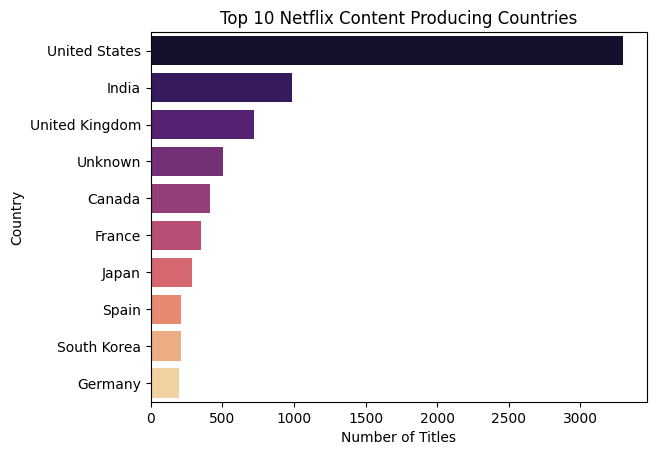

In [80]:
# Top 10 Countries
top_countries = country_count.head(10)

sns.barplot(x='Count', y='Country', data=top_countries, palette='magma')
plt.title("Top 10 Netflix Content Producing Countries")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()


In [136]:
# Step 3: Country-wise Content Contribution

# Fill missing country values
data['Country'] = data['Country'].fillna('Unknown')

# Split multiple countries (like "United States, India") into lists
data['Country'] = data['Country'].str.split(', ')

# Explode lists into separate rows
data_exploded = data.explode('Country')

# Count content per country
country_count = data_exploded['Country'].value_counts().reset_index()
country_count.columns = ['Country', 'Count']

# Show top 10 countries
country_count.head(10)


,Country,Count


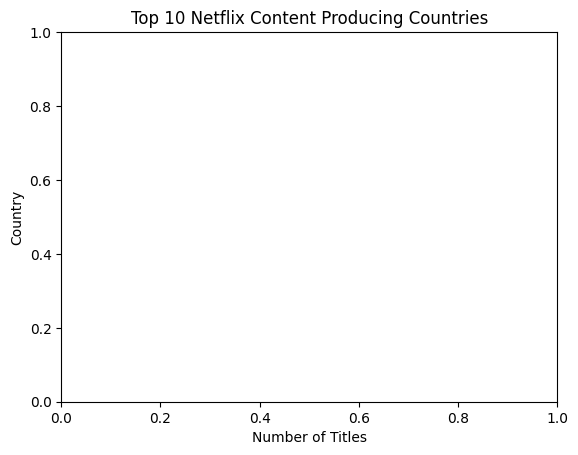

In [137]:
# Top 10 Countries
top_countries = country_count.head(10)

sns.barplot(x='Count', y='Country', data=top_countries, palette='magma')
plt.title("Top 10 Netflix Content Producing Countries")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()

In [85]:
country_count.head(10)


,Country,Count
0,United States,3297
1,India,990
2,United Kingdom,722
3,Unknown,507
4,Canada,412
5,France,349
6,Japan,287
7,Spain,215
8,South Korea,212
9,Germany,199


In [87]:
yearly_content = data.groupby('Year').size().reset_index(name='Total_Content')


In [90]:
yearly_content.head(20)


,Year,Total_Content
0,2008.0,2
1,2009.0,2
2,2010.0,1
3,2011.0,13
4,2012.0,3
5,2013.0,10
6,2014.0,24
7,2015.0,79
8,2016.0,432
9,2017.0,1201


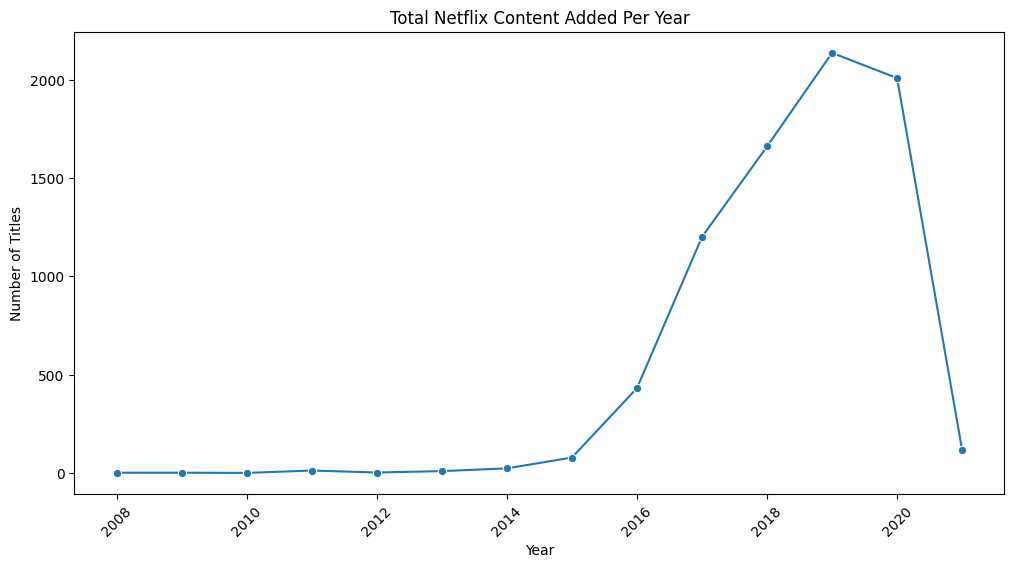

In [88]:
plt.figure(figsize=(12,6))
sns.lineplot(x='Year', y='Total_Content', data=yearly_content, marker='o')
plt.title("Total Netflix Content Added Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()


In [98]:
data.Duration.unique()


array(['4 Seasons', '93 min', '78 min', '80 min', '123 min', '1 Season',
       '95 min', '119 min', '118 min', '143 min', '103 min', '89 min',
       '91 min', '149 min', '144 min', '124 min', '87 min', '110 min',
       '128 min', '117 min', '100 min', '2 Seasons', '84 min', '99 min',
       '90 min', '102 min', '104 min', '105 min', '56 min', '125 min',
       '81 min', '97 min', '106 min', '107 min', '109 min', '44 min',
       '75 min', '101 min', '3 Seasons', '37 min', '113 min', '114 min',
       '130 min', '94 min', '140 min', '135 min', '82 min', '70 min',
       '121 min', '92 min', '164 min', '53 min', '83 min', '116 min',
       '86 min', '120 min', '96 min', '126 min', '129 min', '77 min',
       '137 min', '148 min', '28 min', '122 min', '176 min', '85 min',
       '22 min', '68 min', '111 min', '29 min', '142 min', '168 min',
       '21 min', '59 min', '20 min', '98 min', '108 min', '76 min',
       '26 min', '156 min', '30 min', '57 min', '150 min', '133 min',
       '1

In [100]:
data.Duration.dtypes

dtype('O')

In [103]:
data[['Minutes', 'Unit']]= data['Duration'].str.split(' ', expand = True)

In [104]:
data['Minutes'].max()

'99'

In [105]:
# Filter Movies
movies = data[data['Type'] == 'Movie']

# Remove ' min' and convert to numeric
movies['Duration'] = movies['Duration'].str.replace(' min', '').astype(float)




In [109]:
data['Type'] = data['Type'].str.strip().str.title()


In [111]:
print(data['Duration'].head(10))


0    4 Seasons
1       93 min
2       78 min
3       80 min
4      123 min
5     1 Season
6       95 min
7      119 min
8      118 min
9      143 min
Name: Duration, dtype: object


In [112]:
movies = data[data['Type'] == 'Movie'].copy()
print(movies.shape)  # should show some rows


(0, 14)


In [114]:
print(data['Year'].head())


0    2020.0
1    2016.0
2    2018.0
3    2017.0
4    2020.0
Name: Year, dtype: float64


In [115]:
movie_duration_trend = movies.groupby('Year')['Duration'].mean().reset_index()
print(movie_duration_trend)


Empty DataFrame
Columns: [Year, Duration]
Index: []


In [121]:

# Remove extra spaces and standardize capitalization
data['Type'] = data['Type'].str.strip().str.lower()


In [122]:
# Remove extra spaces and standardize capitalization
data['Type'] = data['Type'].str.strip().str.lower()


In [123]:
movies = data[data['Type'] == 'movie'].copy()
print(f"Number of Movies: {movies.shape[0]}")


Number of Movies: 0


In [124]:
print(data['Type'].unique())


['international tv shows, tv dramas, tv sci-fi & fantasy'
 'dramas, international movies' 'horror movies, international movies'
 'action & adventure, independent movies, sci-fi & fantasy' 'dramas'
 'international tv shows, tv dramas, tv mysteries'
 'horror movies, international movies, thrillers' 'dramas, thrillers'
 'crime tv shows, international tv shows, tv dramas'
 'crime tv shows, docuseries, international tv shows'
 'documentaries, international movies, sports movies'
 'independent movies, sci-fi & fantasy, thrillers'
 'dramas, international movies, thrillers'
 'international tv shows, tv dramas'
 'comedies, dramas, independent movies' 'sports movies'
 'dramas, independent movies, international movies'
 'action & adventure, dramas, international movies'
 'anime series, international tv shows' 'documentaries' 'reality tv'
 'documentaries, international movies' 'tv comedies'
 'dramas, international movies, romantic movies' 'comedies'
 'comedies, romantic movies' 'documentaries, spo

In [125]:
# Filter rows where 'Type' contains 'movie'
movies = data[data['Type'].str.lower().str.contains('movie')].copy()
print(f"Number of Movies: {movies.shape[0]}")



Number of Movies: 3939


In [126]:
movies['Duration'] = movies['Duration'].str.extract(r'(\d+)')
movies['Duration'] = pd.to_numeric(movies['Duration'], errors='coerce')
movies = movies.dropna(subset=['Duration', 'Year'])


In [127]:
movie_duration_trend = movies.groupby('Year')['Duration'].mean().reset_index()
print(movie_duration_trend.head())


     Year  Duration
0  2008.0      81.0
1  2009.0      66.5
2  2010.0      84.0
3  2011.0      91.0
4  2012.0      26.0


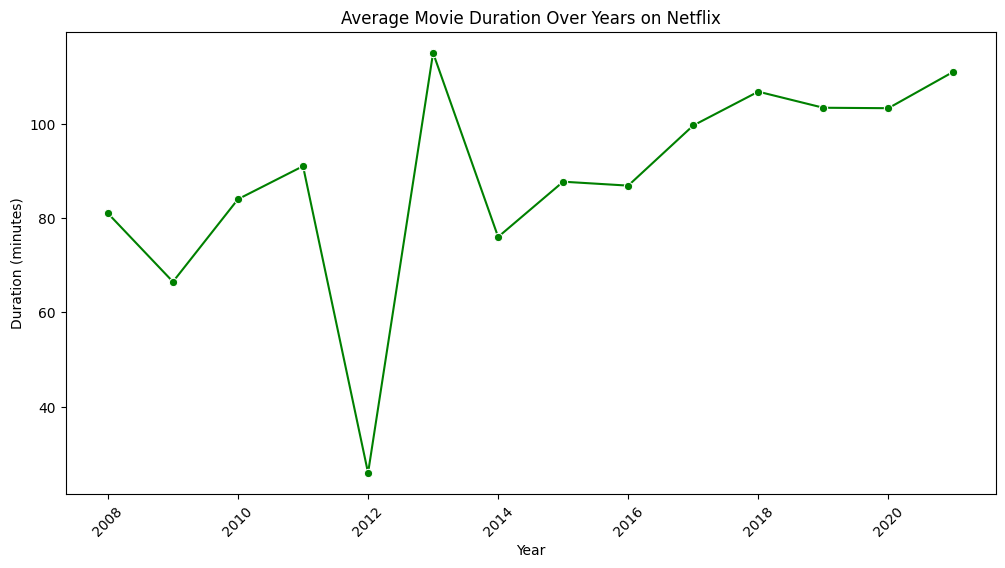

In [128]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.lineplot(x='Year', y='Duration', data=movie_duration_trend, marker='o', color='green')
plt.title("Average Movie Duration Over Years on Netflix")
plt.xlabel("Year")
plt.ylabel("Duration (minutes)")
plt.xticks(rotation=45)
plt.show()


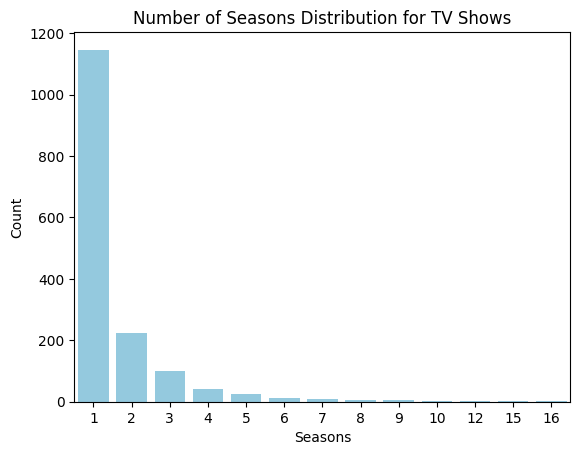

In [133]:
sns.barplot(x='Seasons', y='Count', data=season_distribution, color='skyblue')
plt.title("Number of Seasons Distribution for TV Shows")
plt.xlabel("Seasons")
plt.ylabel("Count")
plt.show()


In [142]:
import pandas as pd

# Standardize Type column
data['Type'] = data['Type'].str.lower()

# Filter Movies and TV Shows
movies = data[data['Type'].str.contains('movie', na=False)]
tv_shows = data[data['Type'].str.contains('tv show', na=False)]

# Count Ratings for Movies
movie_rating_count = movies['Rating'].value_counts().reset_index()
movie_rating_count.columns = ['Rating', 'Count']
movie_rating_count = movie_rating_count.sort_values(by='Count', ascending=False)
print("Movie Ratings Count:")
print(movie_rating_count)

# Count Ratings for TV Shows
tv_rating_count = tv_shows['Rating'].value_counts().reset_index()
tv_rating_count.columns = ['Rating', 'Count']
tv_rating_count = tv_rating_count.sort_values(by='Count', ascending=False)
print("\nTV Show Ratings Count:")
print(tv_rating_count)


Movie Ratings Count:
      Rating  Count
0      TV-MA   1284
1      TV-14   1051
2      TV-PG    389
3          R    384
4         PG    214
5      PG-13    203
6       TV-Y    117
7      TV-Y7     95
8       TV-G     92
9         NR     58
10         G     36
11  TV-Y7-FV      5
12        UR      4
13     NC-17      3

TV Show Ratings Count:
  Rating  Count
0  TV-MA    783
1  TV-14    523
2  TV-PG    175
3   TV-G     32
4   TV-Y     29
5  TV-Y7     24
6     NR      3
7      R      2
